In [12]:
# Análisis Exploratorio de las compras ventas en Amazon

Este notebook explora compras em Amazon (e-commerce), con el objetivo de responder:

- ¿Qué categorías generan más ventas?
- ¿Qué productos tienen mejor valoración?
- ¿Existe relación entre precio y rating?
- ¿Qué productos concentran más reseñas?
- ¿Hay estacionalidad en las compras?
- ¿Qué marcas dominan cada categoría?

In [13]:
# ----------------------------------------------------------
# Librerías y carga de datos
# ----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Estilo de gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

# Cargar datos
df = pd.read_csv("../data/amazon.csv")

# Primer vistazo al dataset
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Descripción de columnas

- `product_id`: ID del producto
- `product_name`: Nombre del producto
- `category`: Categoría
- `discounted_price`: Precio con descuento
- `actual_price`: Precio original antes del descuento
- `discount_percentage`: Porcentaje de descuento
- `rating`: Calificacion del producto
- `rating_count`: Cantidad de valoraciones
- `about_product`: Detalles del producto
- `user_id`: ID usuario de reseña
- `user_name`: Nombre suario de reseña
- `review_id`: ID de la reseña
- `review_title`: Título de la reseña
- `review_content`: Contenido de la reseña
- `img_link`: Imagen del producto
- `product_link`: URL del producto

7
category_level_1
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


Text(0, 0.5, 'Categoría nivel 1')

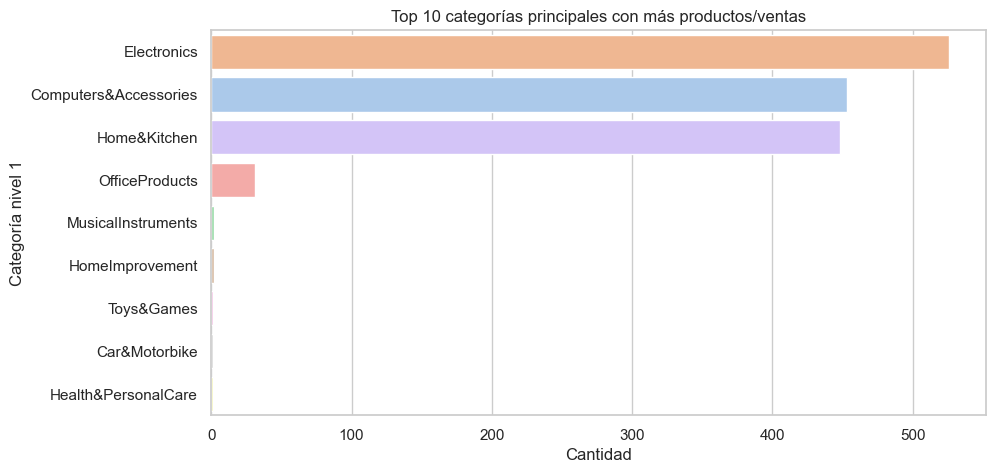

In [14]:
# ----------------------------------------------------------
# Limpieza y tratamiento de datos
# ----------------------------------------------------------

# Rellenamos columnas importantes
df['rating_count'] = df['rating_count'].fillna(0)

# Quitamos caracteres ₹
df['discounted_price'] = (df['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False))
df['actual_price'] = (df['actual_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False))

# Quitamos caracteres %
df['discount_percentage'] = (df['discount_percentage'].str.replace('%', '', regex=False))

# Convertir las columnas de tipo
cols = ['discounted_price', 'actual_price', 'discount_percentage']
df[cols] = df[cols].apply(pd.to_numeric)
# ----------------------------------------------------------
# Análisis exploratorio
# ----------------------------------------------------------
# 1 Categorías con más ventas
# Calcular número máximo de niveles en 'category' (raw string para la barra)
max_levels = df['category'].str.count(r'\|').max() + 1
cols = [f'category_level_{i+1}' for i in range(max_levels)]

# Dividir categorías y asignar a nuevas columnas
df[cols] = df['category'].str.split('|', expand=True)

# Contar ventas por categoría nivel 1
ventas_por_categoria = df['category_level_1'].value_counts()
print(ventas_por_categoria)

# Seleccionar las 10 categorías principales para graficar
top_categories = ventas_por_categoria.head(10).index

# Graficar top 10 categorías nivel 1
sns.countplot(
    data=df[df['category_level_1'].isin(top_categories)],
    y='category_level_1',
    order=top_categories,
    hue='category_level_1',
    palette='pastel',
    legend=False
)

plt.title('Top 10 categorías principales con más productos/ventas')
plt.xlabel('Cantidad')
plt.ylabel('Categoría nivel 1')

# Mostramos gráfico
# plt.show()

**Conclusión:**  
La categoría más vendida es Electrónica, que representa un 35,9% de las ventas, seguida de cerca por Ordenadores y Accesorios, con aproximadamente un 30% de las ventas totales.